# Evaluation and Interpretation

This notebook evaluates the three predictive models developed and frozen in `03-model-development.ipynb` using the held-out NHANES test cohort.

The test cohort was separated from the training cohort before metabolic phenotype discovery and was not used for model fitting or hyperparameter selection. The fitted training-set scaler and K-means model were used previously to assign test participants to the learned metabolic phenotypes.

Three models are evaluated:

1. Logistic regression baseline
2. XGBoost without metabolic phenotype
3. XGBoost with metabolic phenotype

The frozen models are applied to the held-out test cohort once. Their predictions are then used to compare overall predictive performance, assess whether adding metabolic phenotype improves prediction, examine performance within each metabolic phenotype, and interpret XGBoost predictions using SHAP.

## Loading the held-out test cohort and fitted models

The held-out test cohort from `02-metabolic-phenotyping.ipynb` is loaded from `test_clustered.csv`.

The three fitted model pipelines saved in `03-model-development.ipynb` are loaded from `data/models`. These pipelines already contain the preprocessing transformations and model parameters learned exclusively from the training cohort.

No preprocessing or model fitting is repeated in this notebook.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = DATA_DIR / "models"
RESULTS_DIR = Path("../results")

TEST_DATA_PATH = PROCESSED_DIR / "test_clustered.csv"

test_df = pd.read_csv(TEST_DATA_PATH)

logistic_model = joblib.load(
    MODEL_DIR / "logistic_regression.joblib"
)

xgb_base_model = joblib.load(
    MODEL_DIR / "xgboost_without_phenotype.joblib"
)

xgb_phenotype_model = joblib.load(
    MODEL_DIR / "xgboost_with_phenotype.joblib"
)

print(f"Test participants: {len(test_df):,}")
print("\nOutcome distribution:")
print(test_df["hepatic_steatosis"].value_counts().sort_index())

print("\nMetabolic phenotypes:")
print(test_df["metabolic_phenotype"].value_counts())

Test participants: 654

Outcome distribution:
hepatic_steatosis
0    278
1    376
Name: count, dtype: int64

Metabolic phenotypes:
metabolic_phenotype
Lower metabolic-risk     357
Higher metabolic-risk    297
Name: count, dtype: int64


## Preparing the held-out test predictors

The same predictor sets defined during model development are reconstructed from the held-out test cohort.

The base predictor set contains the 11 demographic, anthropometric, clinical and metabolic variables used by logistic regression and XGBoost without phenotype information. The phenotype-enhanced predictor set additionally contains `metabolic_phenotype`.

`SEQN`, CAP, the numerical cluster label and the hepatic steatosis outcome are not included as predictors.

The true hepatic steatosis outcome is retained separately as `y_test` so that the model predictions can subsequently be compared with the known CAP-derived outcome.

In [2]:
numeric_features = [
    "age",
    "bmi",
    "waist_cm",
    "systolic_bp",
    "diastolic_bp",
    "hdl_mg_dl",
    "triglycerides_mg_dl",
    "glucose_mg_dl",
]

categorical_features = [
    "sex",
    "race_ethnicity",
    "diabetes_status",
]

base_features = numeric_features + categorical_features
features_with_phenotype = base_features + ["metabolic_phenotype"]

X_test_base = test_df[base_features].copy()
X_test_with_phenotype = test_df[features_with_phenotype].copy()

y_test = test_df["hepatic_steatosis"].copy()

print(f"X_test_base:            {X_test_base.shape}")
print(f"X_test_with_phenotype:  {X_test_with_phenotype.shape}")
print(f"y_test:                 {y_test.shape}")

# Validate the held-out test cohort
required_columns = (
    ["SEQN", "hepatic_steatosis", "metabolic_phenotype"]
    + features_with_phenotype
)

assert set(required_columns).issubset(test_df.columns)
assert test_df["SEQN"].is_unique
assert test_df[required_columns].notna().all().all()
assert set(y_test.unique()) == {0, 1}

print("\nTest cohort validation passed.")

X_test_base:            (654, 11)
X_test_with_phenotype:  (654, 12)
y_test:                 (654,)

Test cohort validation passed.


## Generating held-out test predictions

The three frozen model pipelines are now applied to the held-out test cohort.

Each model generates a predicted probability of hepatic steatosis for every test participant. A conventional probability threshold of `0.50` is used to generate binary classifications, where `1` represents predicted hepatic steatosis and `0` represents predicted absence of hepatic steatosis.

The `0.50` threshold was not clinically optimized or selected using the held-out test cohort. It is used as a common reference threshold for comparing classification behaviour across the three models. Consequently, sensitivity and specificity at this threshold should not be interpreted as representing an optimal clinical screening operating point.

The models are not refitted or modified using the test data. These predictions therefore provide the basis for the final held-out evaluation of model performance.

In [3]:
# Generate probabilities from the three frozen models
logistic_probability = logistic_model.predict_proba(
    X_test_base
)[:, 1]

xgb_base_probability = xgb_base_model.predict_proba(
    X_test_base
)[:, 1]

xgb_phenotype_probability = xgb_phenotype_model.predict_proba(
    X_test_with_phenotype
)[:, 1]

# Convert probabilities to binary predictions
threshold = 0.50

logistic_prediction = (
    logistic_probability >= threshold
).astype(int)

xgb_base_prediction = (
    xgb_base_probability >= threshold
).astype(int)

xgb_phenotype_prediction = (
    xgb_phenotype_probability >= threshold
).astype(int)

print(f"Predictions generated: {len(y_test):,}")

print("\nPredicted steatosis cases:")
print(f"Logistic regression:       {logistic_prediction.sum():,}")
print(f"XGBoost:                   {xgb_base_prediction.sum():,}")
print(f"XGBoost + phenotype:       {xgb_phenotype_prediction.sum():,}")

# Validate generated predictions
probability_arrays = [
    logistic_probability,
    xgb_base_probability,
    xgb_phenotype_probability,
]

prediction_arrays = [
    logistic_prediction,
    xgb_base_prediction,
    xgb_phenotype_prediction,
]

for probability in probability_arrays:
    assert len(probability) == len(test_df)
    assert np.isfinite(probability).all()
    assert ((probability >= 0) & (probability <= 1)).all()

for prediction in prediction_arrays:
    assert len(prediction) == len(test_df)
    assert set(np.unique(prediction)).issubset({0, 1})

print("\nPrediction validation passed.")

# Save participant-level predictions
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

predictions = test_df[
    ["SEQN", "hepatic_steatosis", "metabolic_phenotype"]
].copy()

predictions["logistic_probability"] = logistic_probability
predictions["logistic_prediction"] = logistic_prediction

predictions["xgb_probability"] = xgb_base_probability
predictions["xgb_prediction"] = xgb_base_prediction

predictions["xgb_phenotype_probability"] = xgb_phenotype_probability
predictions["xgb_phenotype_prediction"] = xgb_phenotype_prediction

PREDICTIONS_PATH = RESULTS_DIR / "model_predictions.csv"
predictions.to_csv(PREDICTIONS_PATH, index=False)

print(f"\nSaved predictions to: {PREDICTIONS_PATH}")

Predictions generated: 654

Predicted steatosis cases:
Logistic regression:       401
XGBoost:                   414
XGBoost + phenotype:       408

Prediction validation passed.

Saved predictions to: ../results/model_predictions.csv


## Evaluating overall model performance

The predicted probabilities and binary classifications are compared with the known hepatic steatosis outcomes in the held-out test cohort.

**AUROC** measures how well each model discriminates between participants with and without hepatic steatosis across all possible classification thresholds. **Average Precision (AP)** summarizes performance across the precision-recall curve as a weighted mean of precision across increases in recall.

At the fixed `0.50` classification threshold, **sensitivity** measures the proportion of participants with hepatic steatosis correctly identified, while **specificity** measures the proportion without hepatic steatosis correctly identified. **Precision** represents the proportion of positive predictions that are correct, and **accuracy** represents the proportion of all predictions that are correct.

The same test participants and classification threshold are used for all three models to allow direct comparison.

In [4]:
def evaluate_model(y_true, probability, prediction):
    tn, fp, fn, tp = confusion_matrix(
        y_true, prediction
    ).ravel()

    return {
        "AUROC": roc_auc_score(y_true, probability),
        "AP": average_precision_score(y_true, probability),
        "Sensitivity": recall_score(y_true, prediction),
        "Specificity": tn / (tn + fp),
        "Precision": precision_score(y_true, prediction),
        "Accuracy": accuracy_score(y_true, prediction),
    }


performance = pd.DataFrame({
    "Logistic regression": evaluate_model(
        y_test,
        logistic_probability,
        logistic_prediction,
    ),
    "XGBoost": evaluate_model(
        y_test,
        xgb_base_probability,
        xgb_base_prediction,
    ),
    "XGBoost + phenotype": evaluate_model(
        y_test,
        xgb_phenotype_probability,
        xgb_phenotype_prediction,
    ),
}).T

performance.round(3)

,AUROC,AP,Sensitivity,Specificity,Precision,Accuracy
Logistic regression,0.862,0.893,0.832,0.683,0.781,0.769
XGBoost,0.860,0.882,0.856,0.669,0.778,0.777
XGBoost + phenotype,0.860,0.884,0.846,0.676,0.779,0.774


### Overall model performance

All three models demonstrated similar discrimination in the held-out test cohort, with AUROC values of approximately `0.86`.

Logistic regression achieved the highest AUROC (`0.862`) and AP (`0.893`), while XGBoost without phenotype achieved an AUROC of `0.860` and AP of `0.882`. Adding metabolic phenotype to XGBoost produced essentially unchanged AUROC (`0.860`) and a slightly higher AP (`0.884`) than XGBoost without phenotype.

At the `0.50` classification threshold, XGBoost without phenotype achieved the highest sensitivity (`0.856`) and accuracy (`0.777`), while logistic regression achieved the highest specificity (`0.683`) and precision (`0.781`). The phenotype-enhanced XGBoost model produced intermediate threshold-dependent performance.

Overall, these results do not indicate a meaningful improvement in overall predictive performance from explicitly adding metabolic phenotype membership to XGBoost. They also suggest that XGBoost does not substantially outperform the simpler logistic regression baseline in the held-out cohort.

## Evaluating performance within metabolic phenotypes

Overall performance may conceal differences in predictive performance between participants with different metabolic profiles.

The held-out test cohort is therefore separated into the lower and higher metabolic-risk phenotypes identified in `02-metabolic-phenotyping.ipynb`. The same performance metrics are calculated independently within each phenotype for all three models.

This analysis does not retrain or modify the models. It evaluates the predictions already generated by the frozen models within each test-set subgroup.

Phenotype-specific results are interpreted alongside the number of participants and hepatic steatosis prevalence within each subgroup, since subgroup size and outcome distribution can affect the stability and interpretation of performance estimates.

In [5]:
phenotype_results = []

model_outputs = {
    "Logistic regression": (
        logistic_probability,
        logistic_prediction,
    ),
    "XGBoost": (
        xgb_base_probability,
        xgb_base_prediction,
    ),
    "XGBoost + phenotype": (
        xgb_phenotype_probability,
        xgb_phenotype_prediction,
    ),
}

for phenotype in [
    "Lower metabolic-risk",
    "Higher metabolic-risk",
]:
    mask = test_df["metabolic_phenotype"] == phenotype

    y_subgroup = y_test[mask]

    print(f"\n{phenotype}")
    print(f"Participants: {mask.sum():,}")
    print(
        f"Steatosis prevalence: "
        f"{y_subgroup.mean() * 100:.1f}%"
    )

    for model_name, (probability, prediction) in model_outputs.items():
        metrics = evaluate_model(
            y_subgroup,
            probability[mask],
            prediction[mask],
        )

        phenotype_results.append({
            "Phenotype": phenotype,
            "Model": model_name,
            "N": mask.sum(),
            "Steatosis prevalence": y_subgroup.mean(),
            **metrics,
        })

phenotype_performance = pd.DataFrame(phenotype_results)

display(
    phenotype_performance.round(3)
)


Lower metabolic-risk
Participants: 357
Steatosis prevalence: 35.0%

Higher metabolic-risk
Participants: 297
Steatosis prevalence: 84.5%


,Phenotype,Model,N,Steatosis prevalence,AUROC,AP,Sensitivity,Specificity,Precision,Accuracy
0,Lower metabolic-risk,Logistic regression,357,0.350,0.776,0.641,0.568,0.789,0.592,0.711
1,Lower metabolic-risk,XGBoost,357,0.350,0.791,0.627,0.616,0.776,0.597,0.720
2,Lower metabolic-risk,XGBoost + phenotype,357,0.350,0.786,0.619,0.576,0.789,0.595,0.714
3,Higher metabolic-risk,Logistic regression,297,0.845,0.777,0.947,0.964,0.152,0.861,0.838
4,Higher metabolic-risk,XGBoost,297,0.845,0.759,0.935,0.976,0.130,0.860,0.845
5,Higher metabolic-risk,XGBoost + phenotype,297,0.845,0.761,0.936,0.980,0.109,0.857,0.845


### Interpretation of phenotype-specific performance

Model performance differed substantially between the two metabolic phenotypes, particularly for threshold-dependent classification metrics.

Among participants in the **lower metabolic-risk phenotype**, hepatic steatosis prevalence was 35.0%. All three models showed moderate discrimination, with AUROC values ranging from 0.776 to 0.791. At the 0.50 classification threshold, specificity was relatively high (0.776–0.789), while sensitivity was considerably lower (0.568–0.616). This indicates that the models were better at identifying participants without steatosis in this phenotype but missed a substantial proportion of participants with steatosis.

Among participants in the **higher metabolic-risk phenotype**, hepatic steatosis prevalence was substantially higher at 84.5%. AUROC values ranged from 0.759 to 0.777. At the 0.50 threshold, sensitivity was very high (0.964–0.980), while specificity was very low (0.109–0.152). The models therefore identified nearly all participants with steatosis in this phenotype but frequently classified participants without steatosis as positive.

These findings demonstrate that similar overall model performance can conceal substantially different classification behaviour across metabolic phenotypes. The large difference in steatosis prevalence between phenotypes is particularly important when interpreting sensitivity, specificity, precision and accuracy.

Adding metabolic phenotype as an explicit XGBoost predictor did not substantially improve discrimination within either phenotype. The phenotype-specific analysis is therefore more informative as a way of identifying differences in model behaviour between metabolic profiles than as an additional predictive feature.

## Visualizing discrimination across classification thresholds

The preceding sensitivity, specificity and accuracy results depend on the fixed `0.50` classification threshold. To evaluate model discrimination independently of a single threshold, receiver operating characteristic (ROC) and precision-recall (PR) curves are examined.

The **ROC curve** shows the relationship between sensitivity (true-positive rate) and the false-positive rate across all possible classification thresholds. Its overall performance is summarized by AUROC.

The **precision-recall curve** shows the relationship between precision and recall as the classification threshold changes. Its overall performance is summarized by AP.

These curves allow the three models to be compared across a range of possible thresholds rather than only at the `0.50` threshold used for the binary classifications.

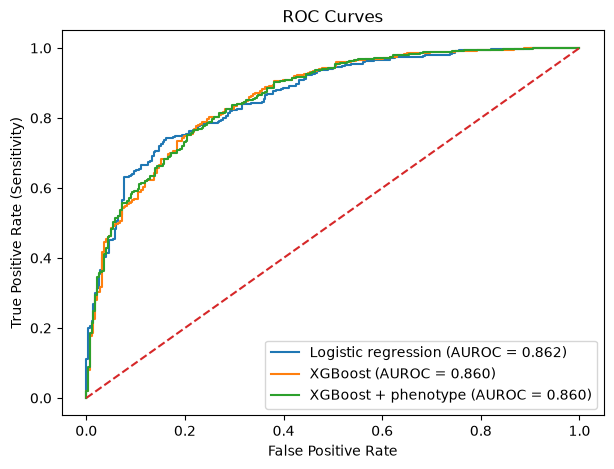

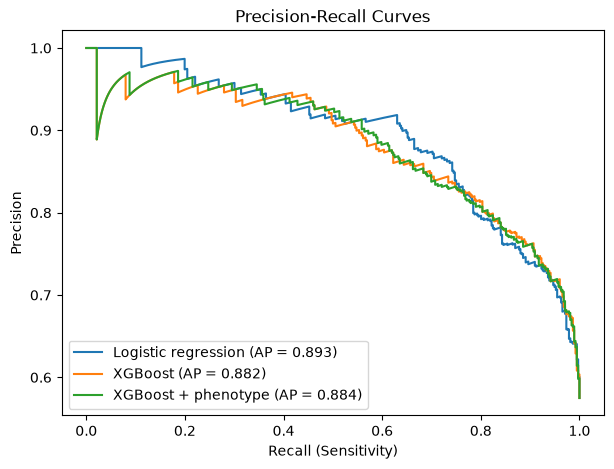

In [6]:
# Store model probabilities for plotting
model_probabilities = {
    "Logistic regression": logistic_probability,
    "XGBoost": xgb_base_probability,
    "XGBoost + phenotype": xgb_phenotype_probability,
}

# ROC curves
plt.figure(figsize=(7, 5))

for model_name, probability in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probability)
    auroc = roc_auc_score(y_test, probability)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUROC = {auroc:.3f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curves")
plt.legend()
plt.show()


# Precision-recall curves
plt.figure(figsize=(7, 5))

for model_name, probability in model_probabilities.items():
    precision, recall, _ = precision_recall_curve(
        y_test,
        probability,
    )

    ap = average_precision_score(
        y_test,
        probability,
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AP = {ap:.3f})",
    )

plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

### Interpretation of discrimination curves

The ROC curves for all three models largely overlap, consistent with their very similar AUROC values. Logistic regression achieved a marginally higher AUROC (`0.862`) than both XGBoost models (`0.860`), indicating no substantial improvement in overall discrimination from the more complex models.

The precision-recall curves show a similar pattern. Logistic regression achieved the highest AP (`0.893`), compared with `0.882` for XGBoost and `0.884` for XGBoost with metabolic phenotype.

Overall, the visual and numerical results indicate that all three models have similar predictive discrimination in the held-out test cohort. Explicitly adding metabolic phenotype membership to XGBoost does not appear to materially improve overall predictive performance.

## Evaluating probability calibration

Discrimination measures such as AUROC and average precision assess how well the models distinguish participants with and without hepatic steatosis, but they do not assess whether the predicted probabilities accurately represent observed outcome frequencies.

Probability calibration is therefore examined using the **Brier score** and calibration curves. The Brier score measures the mean squared difference between predicted probabilities and observed binary outcomes, with lower values indicating better probabilistic accuracy.

Calibration curves group participants according to predicted probability and compare the mean predicted probability within each group with the observed proportion of hepatic steatosis. A well-calibrated model should produce values close to the diagonal reference line.

Calibration is evaluated using the predictions already generated by the frozen models; no model fitting or recalibration is performed.

,Brier score
Logistic regression,0.150
XGBoost,0.149
XGBoost + phenotype,0.150


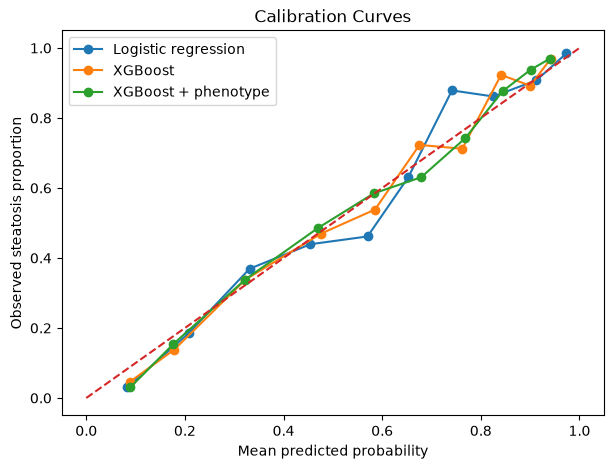

In [7]:
# Calculate Brier scores
brier_scores = pd.Series({
    model_name: brier_score_loss(y_test, probability)
    for model_name, probability in model_probabilities.items()
}, name="Brier score")

display(
    brier_scores.to_frame().round(3)
)


# Plot calibration curves
plt.figure(figsize=(7, 5))

for model_name, probability in model_probabilities.items():
    observed_probability, predicted_probability = calibration_curve(
        y_test,
        probability,
        n_bins=10,
        strategy="quantile",
    )

    plt.plot(
        predicted_probability,
        observed_probability,
        marker="o",
        label=model_name,
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed steatosis proportion")
plt.title("Calibration Curves")
plt.legend()
plt.show()

### Interpretation of probability calibration

All three models showed similar probabilistic performance, with Brier scores of `0.150` for logistic regression, `0.149` for XGBoost and `0.150` for XGBoost with metabolic phenotype. The small numerical differences do not indicate a clear advantage for any model.

The calibration curves generally followed the diagonal reference line, indicating reasonable agreement between predicted probabilities and observed hepatic steatosis frequencies across much of the probability range. Some deviations were present within individual probability groups, but no model showed consistently superior calibration across the full range.

Overall, the calibration analysis is consistent with the discrimination results: XGBoost and the addition of metabolic phenotype did not provide an obvious improvement over the simpler logistic regression model.

## Examining classification errors

While AUROC and AP evaluate model discrimination across thresholds, confusion matrices show the specific classification outcomes produced at the predefined `0.50` probability threshold.

For each model, the confusion matrix displays the numbers of true negatives, false positives, false negatives and true positives in the held-out test cohort. This provides a direct view of the classification errors underlying the sensitivity and specificity results.

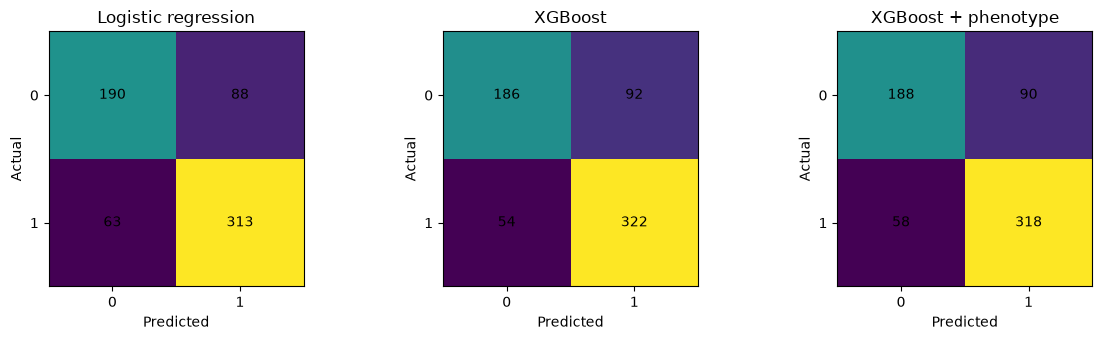

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

models = {
    "Logistic regression": logistic_prediction,
    "XGBoost": xgb_base_prediction,
    "XGBoost + phenotype": xgb_phenotype_prediction,
}

for ax, (model_name, prediction) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, prediction)

    ax.imshow(cm)

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, cm[i, j],
                ha="center",
                va="center",
            )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

plt.tight_layout()
plt.show()

### Interpretation of classification errors

The confusion matrices demonstrate the trade-off between sensitivity and specificity at the predefined `0.50` classification threshold.

Logistic regression correctly identified 313 of the 376 participants with hepatic steatosis, with 63 false-negative classifications. XGBoost without phenotype reduced the number of false negatives to 54 and correctly identified 322 participants with steatosis, but produced slightly more false-positive classifications (92 compared with 88 for logistic regression).

The phenotype-enhanced XGBoost model produced intermediate results, with 318 true positives, 58 false negatives, 90 false positives and 188 true negatives.

These results are consistent with the overall performance metrics. The models demonstrate similar overall discrimination but differ slightly in their balance between sensitivity and specificity at the `0.50` classification threshold.

## Estimating uncertainty in model discrimination

The observed AUROC values are point estimates calculated from the 654 participants in the held-out test cohort. Small differences between these estimates may reflect sampling variation rather than meaningful differences in predictive performance.

Bootstrap resampling is used to estimate 95% confidence intervals for each model's AUROC. The test cohort is repeatedly sampled with replacement, and AUROC is recalculated for each bootstrap sample. The 2.5th and 97.5th percentiles of the resulting AUROC distribution provide the 95% confidence interval.

Bootstrapping does not refit or modify the models. It quantifies uncertainty around the performance of the already-frozen models on the held-out cohort.

In [9]:
from sklearn.utils import resample

N_BOOTSTRAPS = 2000
rng = np.random.default_rng(42)

def bootstrap_auroc(y_true, probability, n_bootstraps=2000):
    y_true = np.asarray(y_true)
    probability = np.asarray(probability)

    scores = []

    for _ in range(n_bootstraps):
        indices = rng.choice(
            len(y_true),
            size=len(y_true),
            replace=True,
        )

        y_sample = y_true[indices]
        probability_sample = probability[indices]

        # AUROC requires both outcome classes
        if len(np.unique(y_sample)) < 2:
            continue

        scores.append(
            roc_auc_score(
                y_sample,
                probability_sample,
            )
        )

    lower, upper = np.percentile(
        scores,
        [2.5, 97.5],
    )

    return lower, upper


auroc_results = []

for model_name, probability in model_probabilities.items():
    auroc = roc_auc_score(y_test, probability)

    lower, upper = bootstrap_auroc(
        y_test,
        probability,
        N_BOOTSTRAPS,
    )

    auroc_results.append({
        "Model": model_name,
        "AUROC": auroc,
        "95% CI lower": lower,
        "95% CI upper": upper,
    })

auroc_ci = pd.DataFrame(auroc_results)

display(
    auroc_ci.set_index("Model").round(3)
)

,AUROC,95% CI lower,95% CI upper
Model,,,
Logistic regression,0.862,0.833,0.888
XGBoost,0.860,0.832,0.886
XGBoost + phenotype,0.860,0.830,0.885


### Interpretation of AUROC uncertainty

All three models achieved similar AUROC estimates with substantially overlapping 95% bootstrap confidence intervals.

Logistic regression achieved an AUROC of `0.862` (95% CI: `0.833–0.888`), compared with `0.860` (`0.832–0.886`) for XGBoost and `0.860` (`0.830–0.885`) for XGBoost with metabolic phenotype.

The small differences in point estimates should therefore not be interpreted as evidence that one model has superior discrimination. A paired comparison of AUROC differences is performed next to directly quantify the uncertainty around the differences between models.

## Comparing AUROC between models

Because all three models are evaluated on the same 654 test participants, their AUROC estimates are paired rather than independent. A paired bootstrap is therefore used to directly estimate uncertainty in the difference in AUROC between models.

The held-out test cohort is repeatedly sampled with replacement. Within each bootstrap sample, AUROC is calculated for both models being compared using the same sampled participants, and the difference between their AUROCs is recorded.

Two comparisons are examined:

1. **XGBoost − Logistic regression**, assessing whether XGBoost improves discrimination over the simpler baseline model.
2. **XGBoost with phenotype − XGBoost without phenotype**, assessing whether explicitly adding metabolic phenotype improves discrimination.

The observed AUROC difference is calculated using the original held-out test cohort, while the 2.5th and 97.5th percentiles of the bootstrap differences form the 95% confidence interval.

If the confidence interval includes zero, the observed results are compatible with no difference in AUROC between the two models.

This procedure does not refit or modify any model. It only quantifies uncertainty in the difference between the predictions already generated by the frozen models.

In [10]:
N_BOOTSTRAPS = 2000
rng = np.random.default_rng(42)

comparisons = [
    (
        "XGBoost - Logistic regression",
        xgb_base_probability,
        logistic_probability,
    ),
    (
        "XGBoost + phenotype - XGBoost",
        xgb_phenotype_probability,
        xgb_base_probability,
    ),
]

difference_results = []

for comparison_name, probability_a, probability_b in comparisons:
    differences = []

    for _ in range(N_BOOTSTRAPS):
        indices = rng.choice(
            len(y_test),
            size=len(y_test),
            replace=True,
        )

        y_sample = np.asarray(y_test)[indices]

        if len(np.unique(y_sample)) < 2:
            continue

        auroc_a = roc_auc_score(
            y_sample,
            np.asarray(probability_a)[indices],
        )

        auroc_b = roc_auc_score(
            y_sample,
            np.asarray(probability_b)[indices],
        )

        differences.append(auroc_a - auroc_b)

    observed_difference = (
        roc_auc_score(y_test, probability_a)
        - roc_auc_score(y_test, probability_b)
    )

    lower, upper = np.percentile(
        differences,
        [2.5, 97.5],
    )

    difference_results.append({
        "Comparison": comparison_name,
        "AUROC difference": observed_difference,
        "95% CI lower": lower,
        "95% CI upper": upper,
    })

auroc_differences = pd.DataFrame(difference_results)

display(
    auroc_differences.set_index("Comparison").round(3)
)

,AUROC difference,95% CI lower,95% CI upper
Comparison,,,
XGBoost - Logistic regression,-0.002,-0.013,0.009
XGBoost + phenotype - XGBoost,0.000,-0.003,0.003


### Comparison of AUROC differences

Paired bootstrap analysis was used to directly quantify uncertainty in the differences in AUROC between models evaluated on the same held-out participants.

The AUROC difference between XGBoost and logistic regression was `−0.002` (95% CI: `−0.013 to 0.009`). The confidence interval includes zero, indicating that the observed difference is compatible with no meaningful difference in discrimination between the two models.

The AUROC difference between XGBoost with and without metabolic phenotype was `0.000` (95% CI: `−0.003 to 0.003`). This interval is narrow and includes zero, providing no evidence that explicitly adding metabolic phenotype membership materially changes XGBoost discrimination in the held-out cohort.

Together with the individual AUROC confidence intervals, these results indicate that all three models provide very similar overall discrimination. The more complex XGBoost models did not demonstrate improved discrimination over logistic regression, and adding metabolic phenotype did not improve XGBoost AUROC.

## Interpreting XGBoost predictions with SHAP

Model performance describes how accurately XGBoost identifies hepatic steatosis but does not explain which predictors contribute most strongly to its predictions.

SHAP (SHapley Additive exPlanations) is used to interpret the fitted XGBoost model. For each test participant, SHAP assigns a contribution to each predictor representing how that predictor influences the model output relative to its baseline.

`TreeExplainer` is used with its default `model_output="raw"`. For binary XGBoost classification, the resulting SHAP values therefore explain changes in the model's raw margin, or log-odds, rather than direct changes in predicted probability.

Positive SHAP values indicate contributions toward a higher predicted probability of hepatic steatosis, while negative values indicate contributions toward a lower predicted probability. Their magnitudes should not be interpreted as absolute changes in probability.

The XGBoost model **without metabolic phenotype** is interpreted first. This allows the contributions of the original demographic, clinical and metabolic predictors to be examined without including the derived phenotype as an additional predictor.

In [11]:
import shap

# Extract the fitted preprocessor and classifier
xgb_preprocessor = xgb_base_model.named_steps["preprocessor"]
xgb_classifier = xgb_base_model.named_steps["classifier"]

# Apply the already-fitted preprocessing to the test predictors
X_test_transformed = xgb_preprocessor.transform(X_test_base)

# Get the transformed feature names
feature_names = xgb_preprocessor.get_feature_names_out()

# Remove preprocessing prefixes for readability
feature_names = [
    name.replace("numeric__", "").replace("categorical__", "")
    for name in feature_names
]

# Explain the fitted XGBoost classifier
explainer = shap.TreeExplainer(xgb_classifier)

shap_values = explainer(X_test_transformed)

print(f"Participants explained: {shap_values.values.shape[0]:,}")
print(f"Transformed predictors: {shap_values.values.shape[1]}")

Participants explained: 654
Transformed predictors: 19


### Overall predictor importance

Global SHAP importance summarizes how strongly each predictor contributes to XGBoost predictions across the held-out test cohort.

Mean absolute SHAP values are used to rank predictors by the average magnitude of their contribution, regardless of whether they increase or decrease predicted steatosis risk.

A SHAP beeswarm plot additionally shows both the magnitude and direction of predictor contributions across individual participants.

,Feature,Mean absolute SHAP
0,waist_cm,0.735
1,glucose_mg_dl,0.350
2,triglycerides_mg_dl,0.329
3,bmi,0.225
4,race_ethnicity_Non-Hispanic Black,0.192
5,age,0.182
6,diastolic_bp,0.135
7,hdl_mg_dl,0.059
8,systolic_bp,0.024
9,race_ethnicity_Non-Hispanic Asian,0.006


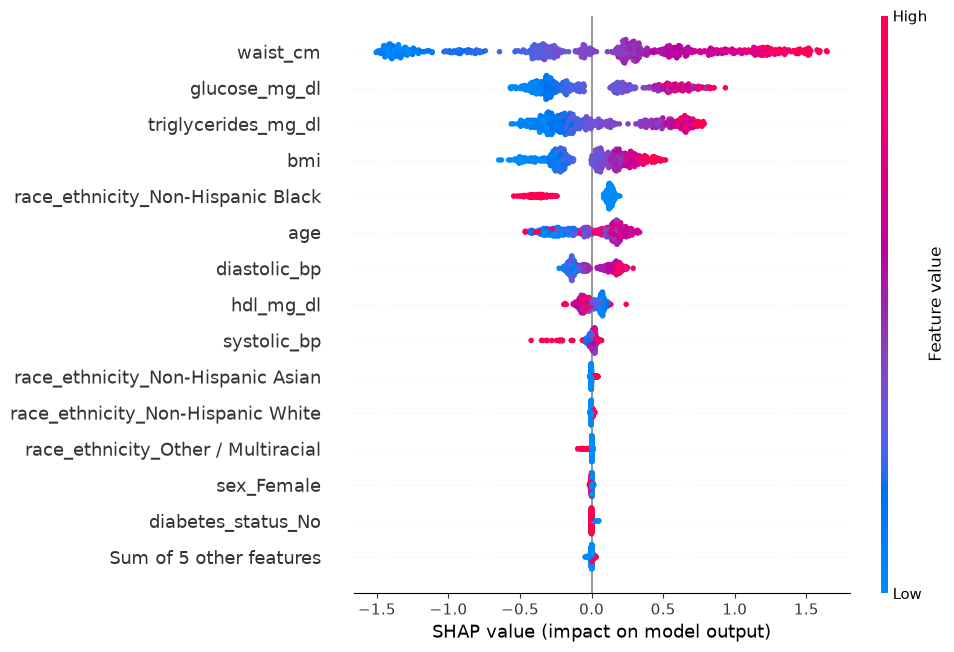

In [12]:
# Mean absolute SHAP importance
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean absolute SHAP": np.abs(shap_values.values).mean(axis=0),
}).sort_values(
    "Mean absolute SHAP",
    ascending=False,
)

display(
    shap_importance.reset_index(drop=True).round(3)
)

# Add readable feature names to the SHAP explanation
shap_values.feature_names = feature_names

# Global SHAP beeswarm plot
shap.plots.beeswarm(
    shap_values,
    max_display=15,
)

### Overall SHAP interpretation

SHAP analysis showed that waist circumference had the strongest average influence on XGBoost predictions across the held-out test cohort (`0.735`), followed by fasting glucose (`0.350`), triglycerides (`0.329`), BMI (`0.225`), the Non-Hispanic Black race/ethnicity indicator (`0.192`), age (`0.182`) and diastolic blood pressure (`0.135`). HDL cholesterol, systolic blood pressure and most remaining categorical indicators had smaller average contributions.

The SHAP beeswarm plot additionally shows the direction of these contributions. Higher waist circumference strongly pushed predictions toward hepatic steatosis, while lower values pushed predictions toward its absence. Higher glucose, triglycerides and BMI showed similar patterns. Higher age and diastolic blood pressure also generally increased the model output, although their contributions were smaller. In contrast, higher HDL cholesterol generally pushed predictions toward lower predicted steatosis risk.

The Non-Hispanic Black race/ethnicity indicator also influenced predictions, with its presence generally producing negative SHAP values. This describes the conditional behavior of the fitted model and should not be interpreted as evidence of a causal relationship.

Overall, the model relied predominantly on measures of central adiposity and metabolic dysfunction, particularly waist circumference, glucose and triglycerides.

## Comparing predictor importance between metabolic phenotypes

To examine whether XGBoost relies on different predictors across metabolic profiles, the SHAP values from the base XGBoost model are separated according to each participant's previously assigned metabolic phenotype.

The model is not retrained within either subgroup. Instead, the same frozen XGBoost model and the same held-out test predictions are interpreted separately for participants in the lower and higher metabolic-risk phenotypes.

Mean absolute SHAP values are calculated within each phenotype to compare the average contribution of each predictor between the two groups.

In [13]:
lower_mask = (
    test_df["metabolic_phenotype"] == "Lower metabolic-risk"
).to_numpy()

higher_mask = (
    test_df["metabolic_phenotype"] == "Higher metabolic-risk"
).to_numpy()

lower_importance = np.abs(
    shap_values.values[lower_mask]
).mean(axis=0)

higher_importance = np.abs(
    shap_values.values[higher_mask]
).mean(axis=0)

phenotype_shap = pd.DataFrame({
    "Feature": feature_names,
    "Lower metabolic-risk": lower_importance,
    "Higher metabolic-risk": higher_importance,
})

phenotype_shap["Difference"] = (
    phenotype_shap["Higher metabolic-risk"]
    - phenotype_shap["Lower metabolic-risk"]
)

phenotype_shap = phenotype_shap.sort_values(
    "Lower metabolic-risk",
    ascending=False,
)

display(
    phenotype_shap.reset_index(drop=True).round(3)
)

,Feature,Lower metabolic-risk,Higher metabolic-risk,Difference
0,waist_cm,0.680,0.802,0.122
1,glucose_mg_dl,0.346,0.354,0.007
2,triglycerides_mg_dl,0.299,0.366,0.067
3,bmi,0.221,0.230,0.009
4,age,0.210,0.147,-0.063
5,race_ethnicity_Non-Hispanic Black,0.189,0.197,0.008
6,diastolic_bp,0.125,0.148,0.023
7,hdl_mg_dl,0.053,0.067,0.014
8,systolic_bp,0.019,0.030,0.011
9,race_ethnicity_Non-Hispanic Asian,0.008,0.004,-0.005


### Phenotype-specific SHAP interpretation

The overall ranking of predictor importance was broadly similar across the two metabolic phenotypes. Waist circumference remained the most influential predictor in both groups, with a larger mean absolute SHAP value in the higher metabolic-risk phenotype (`0.802`) than in the lower metabolic-risk phenotype (`0.680`). Triglycerides also showed a larger average SHAP magnitude in the higher-risk phenotype (`0.366` vs. `0.299`), while age showed a larger value in the lower-risk phenotype (`0.210` vs. `0.147`).

Glucose and BMI showed similar average contributions across phenotypes, while most remaining predictors demonstrated relatively small differences.

These subgroup differences are descriptive and should be interpreted cautiously. Mean absolute SHAP values depend partly on the predictor values observed within each subgroup, and the metabolic phenotypes themselves were constructed from several of these predictors. Differences in SHAP magnitude may therefore partly reflect differences in predictor distributions between phenotypes rather than fundamentally different predictive relationships.

Overall, the model relied on broadly similar predictors across both metabolic phenotypes, with some variation in their average contribution magnitudes.

## Conclusion

Routinely available demographic, anthropometric and metabolic variables showed good overall ability to discriminate hepatic steatosis in the held-out NHANES test cohort, with all three models achieving an AUROC of approximately `0.86`.

Increasing model complexity did not materially improve discrimination. Logistic regression achieved an AUROC of `0.862`, compared with `0.860` for both XGBoost models. Paired bootstrap analysis showed no clear difference between logistic regression and XGBoost (ΔAUROC `−0.002`, 95% CI `−0.013 to 0.009`). Explicitly adding metabolic phenotype membership to XGBoost also produced essentially no change in discrimination (ΔAUROC `0.000`, 95% CI `−0.003 to 0.003`). These findings suggest that nonlinear modelling and explicit phenotype membership provided little additional predictive information beyond the routinely available variables themselves.

Metabolic phenotyping nevertheless revealed substantial heterogeneity within the study population. Hepatic steatosis prevalence was `35.0%` in the lower metabolic-risk phenotype compared with `84.5%` in the higher metabolic-risk phenotype. At the predefined `0.50` threshold, the models achieved relatively high specificity but lower sensitivity in the lower-risk phenotype, whereas the higher-risk phenotype showed very high sensitivity (`0.964–0.980`) but poor specificity (`0.109–0.152`). Thus, steatosis was detected much more sensitively among participants with the higher-risk metabolic profile, but with a substantial false-positive trade-off.

SHAP analysis showed that XGBoost relied primarily on waist circumference, fasting glucose, triglycerides and BMI. Predictor importance was broadly similar between phenotypes, although waist circumference and triglycerides contributed more strongly in the higher metabolic-risk phenotype, while age contributed more strongly in the lower metabolic-risk phenotype.

Overall, the findings suggest that the main value of metabolic phenotyping in this analysis is **risk stratification and identification of differences in screening behaviour rather than improvement of predictive discrimination**. The results also demonstrate that greater model complexity does not necessarily translate into better prediction: a comparatively simple logistic regression model performed similarly to tuned XGBoost using the same routinely available clinical information.